In [1]:
import pandas as pd

# Load the dataset
df = pd.read_csv('diabetes_imbalanced_shuffled.csv')

# Show the first few rows to understand the data structure
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,3,111,90,12,78,28.4,0.495,29,0
1,2,94,76,18,66,31.6,0.649,23,0
2,0,177,60,29,478,34.6,1.072,21,1
3,2,107,74,30,100,33.6,0.404,23,0
4,0,78,88,29,40,36.9,0.434,21,0


In [2]:
# Basic info
df.info()

# Check for missing values
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               600 non-null    int64  
 1   Glucose                   600 non-null    int64  
 2   BloodPressure             600 non-null    int64  
 3   SkinThickness             600 non-null    int64  
 4   Insulin                   600 non-null    int64  
 5   BMI                       600 non-null    float64
 6   DiabetesPedigreeFunction  600 non-null    float64
 7   Age                       600 non-null    int64  
 8   Outcome                   600 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 42.3 KB


Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [3]:
# List columns to find target variable
print(df.columns)


Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')


In [98]:
target_col = 'Outcome'  # target 


Outcome
0    500
1    100
Name: count, dtype: int64


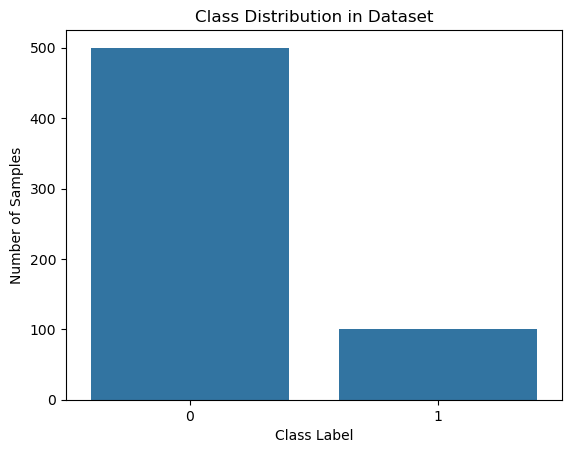

In [5]:
class_counts = df[target_col].value_counts()
print(class_counts)

# Visualize class imbalance with a bar plot
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x=class_counts.index, y=class_counts.values)
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in Dataset')
plt.show()


In [6]:
majority_class_count = class_counts.max()
minority_class_count = class_counts.min()

imbalance_ratio = majority_class_count / minority_class_count
print(f"Imbalance ratio (majority/minority): {imbalance_ratio:.2f}")


Imbalance ratio (majority/minority): 5.00


In [7]:
summary = {
    'Total Samples': len(df),
    'Number of Features': df.shape[1] - 1,  # excluding target
    'Majority Class Count': majority_class_count,
    'Minority Class Count': minority_class_count,
    'Imbalance Ratio': imbalance_ratio
}

summary_df = pd.DataFrame([summary])
summary_df


,Total Samples,Number of Features,Majority Class Count,Minority Class Count,Imbalance Ratio
0,600,8,500,100,5.0


In [8]:
import numpy as np

import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler

# Extract minority class data (Outcome == 1)
minority_data = df[df[target_col] == 1].drop(columns=[target_col])

# Scale data to range [-1, 1] or [0, 1] depending on activation function used in GAN
scaler = MinMaxScaler(feature_range=(-1, 1))
minority_scaled = scaler.fit_transform(minority_data)

print("Minority data shape:", minority_scaled.shape)


Minority data shape: (100, 8)


In [9]:
import tensorflow as tf
from tensorflow.keras import layers

latent_dim = 100  
learning_rate = 0.0002
beta_1 = 0.5
beta_2 = 0.999
adam_optimizer = Adam(learning_rate=learning_rate, beta_1=beta_1, beta_2=beta_2)
# Generator Model
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(64, activation='relu', input_dim=latent_dim),
        layers.Dense(128, activation='relu'),
        layers.Dense(minority_scaled.shape[1], activation='tanh')  # output scaled to [-1,1]
    ])
    return model

# Build Discriminator model with BatchNorm and LeakyReLU
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Dense(128, input_shape=(minority_scaled.shape[1],)),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Dense(64),
        layers.LeakyReLU(alpha=0.2),
        layers.BatchNormalization(),
        layers.Dense(1, activation='sigmoid')  # output probability
    ])
    return model




In [10]:
# Build models
generator = build_generator()
discriminator = build_discriminator()
discriminator.compile(optimizer=adam_optimizer, loss='binary_crossentropy', metrics=['accuracy'])


# GAN Model 
discriminator.trainable = False
gan_input = layers.Input(shape=(latent_dim,))
generated_sample = generator(gan_input)
gan_output = discriminator(generated_sample)
gan = tf.keras.Model(gan_input, gan_output)
gan.compile(optimizer='adam', loss='binary_crossentropy')

import matplotlib.pyplot as plt

def train_gan(generator, discriminator, gan, data, epochs=1000, batch_size=32, sample_interval=200):
    batch_count = data.shape[0] // batch_size

    for epoch in range(epochs):
        for _ in range(batch_count):
            
            #  Train Discriminator
            

            # Select a random batch of real samples
            idx = np.random.randint(0, data.shape[0], batch_size)
            real_samples = data[idx]

            # Generate fake samples
            noise = np.random.normal(0, 1, (batch_size, latent_dim))
            fake_samples = generator.predict(noise)

            # Labels for real and fake data
            real_labels = np.ones((batch_size, 1))
            fake_labels = np.zeros((batch_size, 1))

            # Train discriminator on real and fake data
            d_loss_real = discriminator.train_on_batch(real_samples, real_labels)
            d_loss_fake = discriminator.train_on_batch(fake_samples, fake_labels)
            d_loss = 0.5 * np.add(d_loss_real, d_loss_fake)

            
            #  Train Generator
           

            noise = np.random.normal(0, 1, (batch_size, latent_dim))
            valid_labels = np.ones((batch_size, 1))  # want generator to fool discriminator

            g_loss = gan.train_on_batch(noise, valid_labels)

        # Print the progress
        
            print(f"Epoch {epoch + 1}/{epochs} [D loss: {d_loss[0]:.4f}, acc.: {100*d_loss[1]:.2f}%] [G loss: {g_loss:.4f}]")
            

C:\Users\96277\ds\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\96277\ds\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [11]:
train_gan(generator, discriminator, gan, minority_scaled, epochs=1000, batch_size=64, sample_interval=1000)


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step 


C:\Users\96277\ds\Lib\site-packages\keras\src\backend\tensorflow\trainer.py:82: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 1/1000 [D loss: 0.7326, acc.: 17.97%] [G loss: 0.6949]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Epoch 2/1000 [D loss: 0.7207, acc.: 25.00%] [G loss: 0.6881]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Epoch 3/1000 [D loss: 0.7220, acc.: 23.07%] [G loss: 0.6834]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Epoch 4/1000 [D loss: 0.7235, acc.: 20.79%] [G loss: 0.6793]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Epoch 5/1000 [D loss: 0.7254, acc.: 18.71%] [G loss: 0.6759]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Epoch 6/1000 [D loss: 0.7275, acc.: 16.54%] [G loss: 0.6738]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
Epoch 7/1000 [D loss: 0.7291, acc.: 15.12%] [G loss: 0.6718]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Epoch 8/1000 [D loss: 0.7303, acc.: 14.43%] [G loss: 0.6699]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Epoch 9/1000 [D loss: 0.7316, acc.: 13.67%] [G loss: 0.6683]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Epoch 10/1000 [D loss: 0.7321, acc.: 13.15%] [G loss: 0.6669]
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Epoch 11/

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


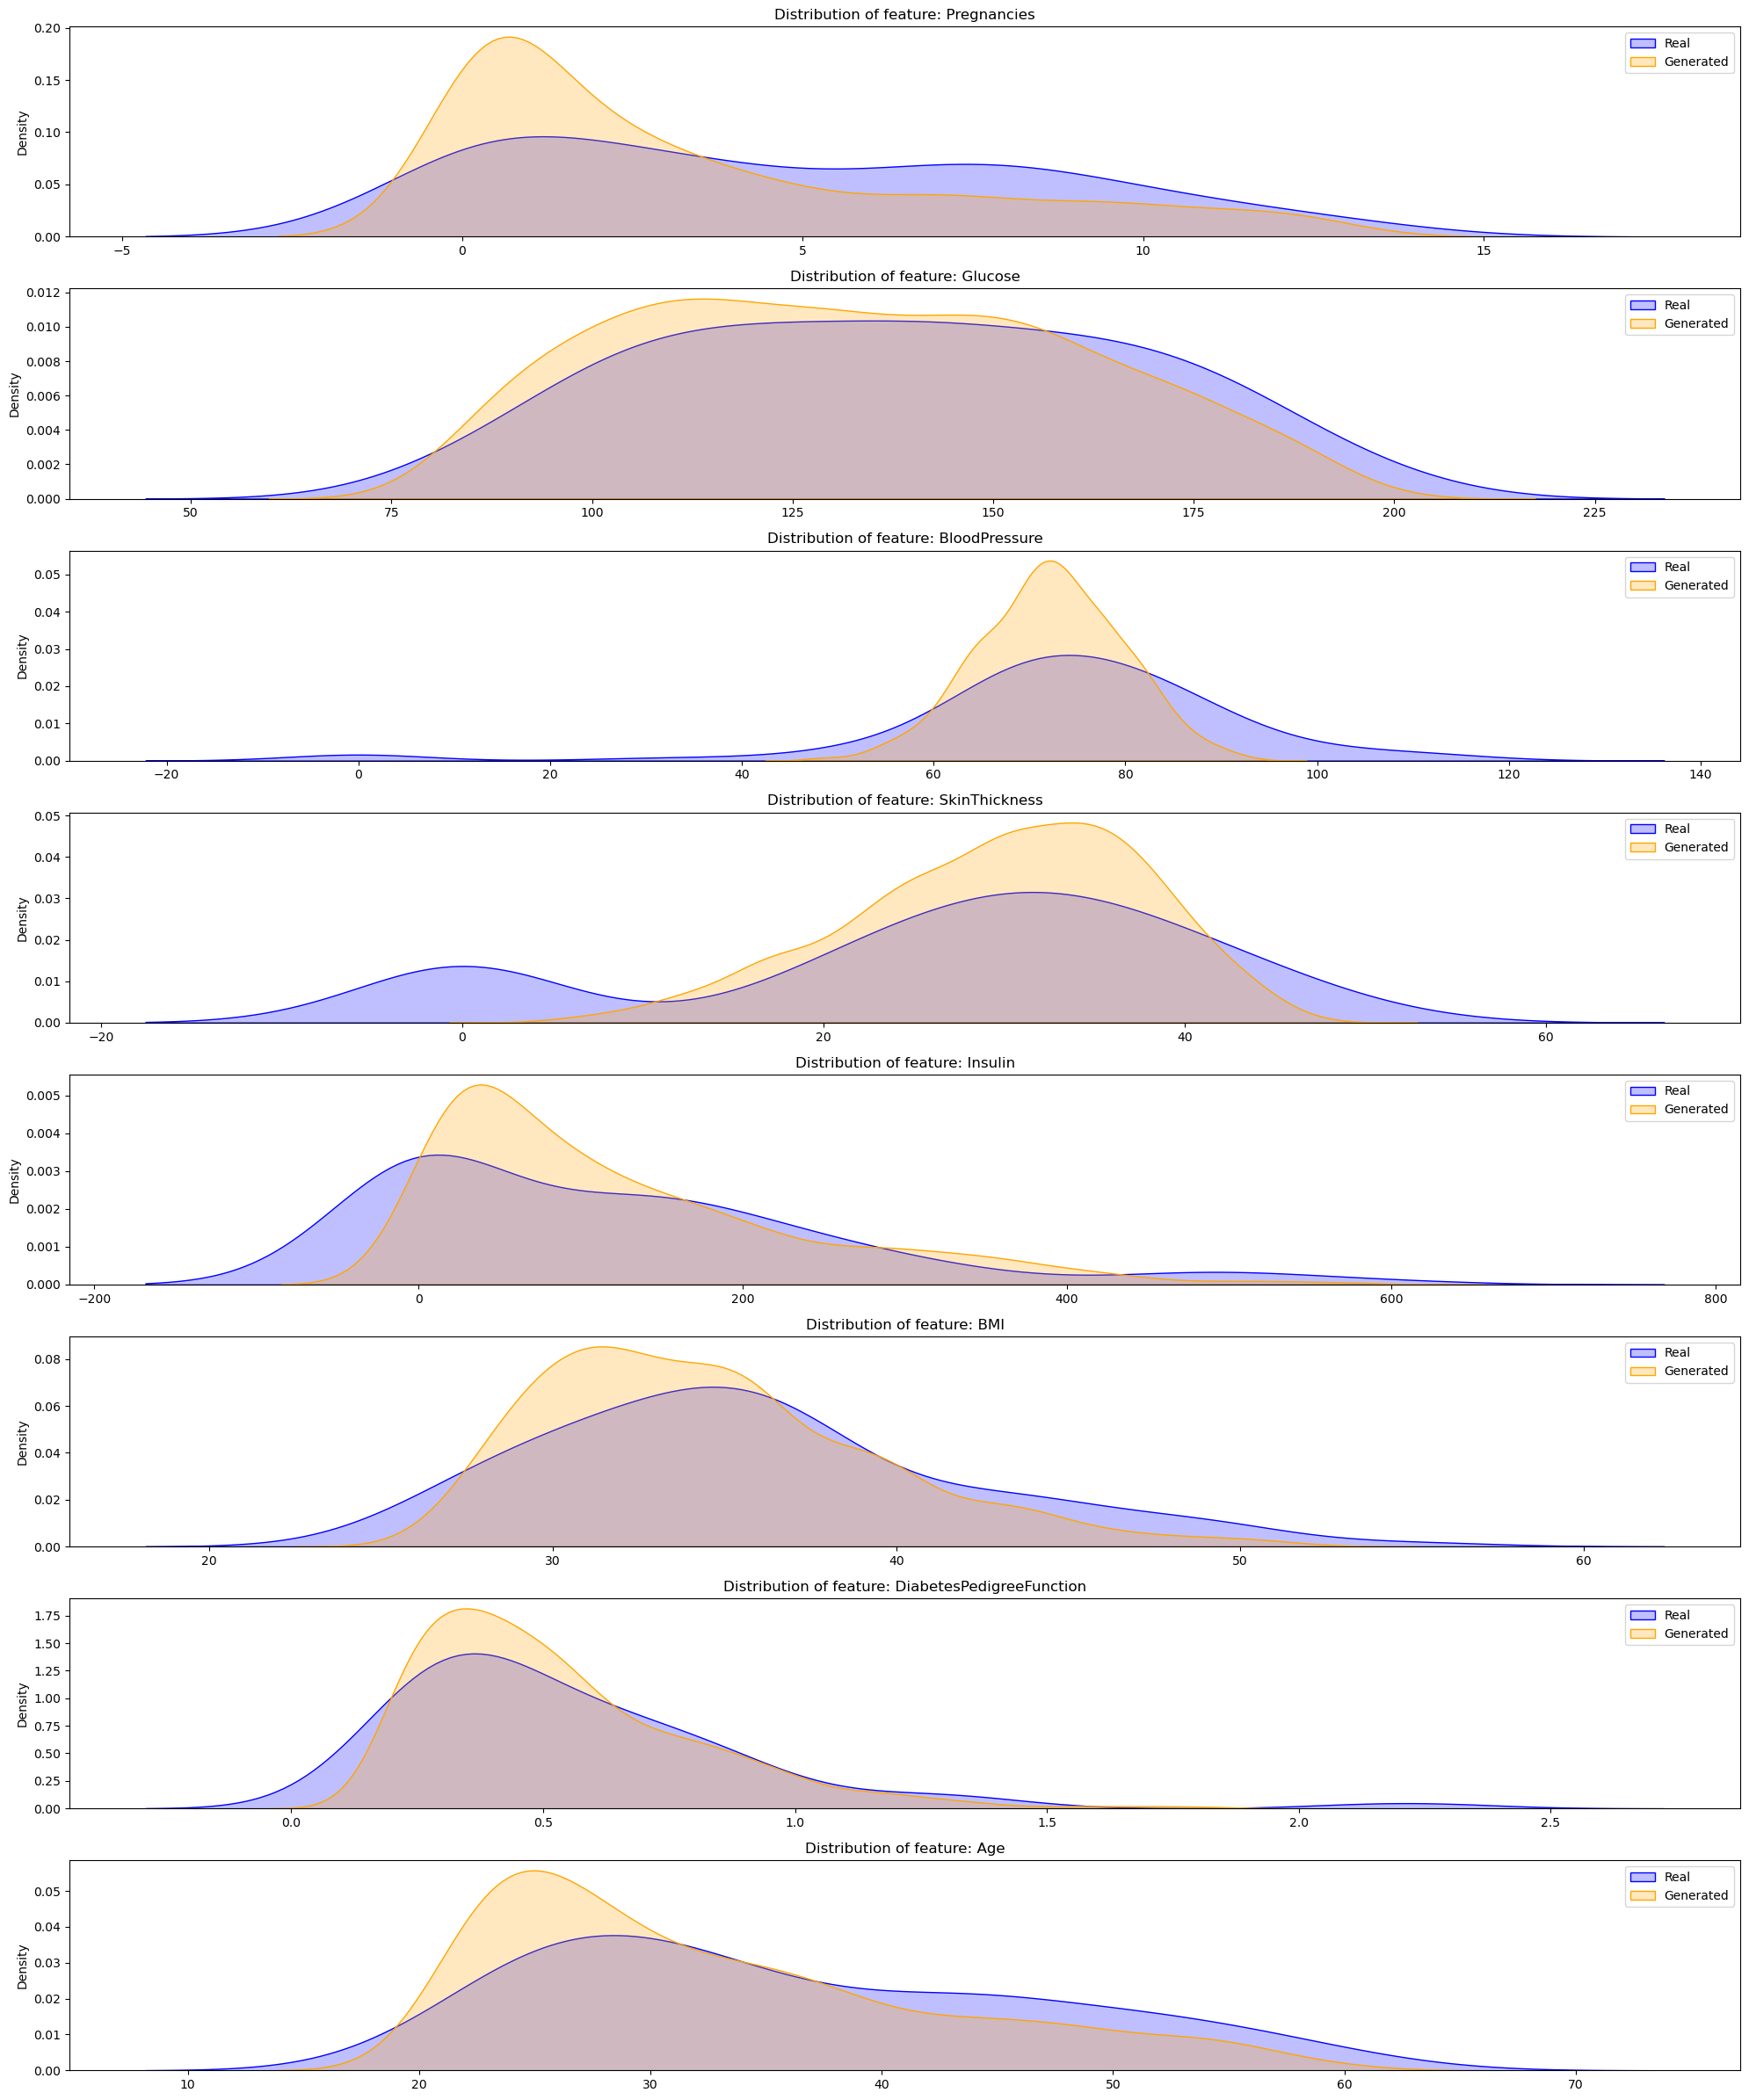

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_distributions(real_data, generated_data, feature_names):
    n_features = real_data.shape[1]
    plt.figure(figsize=(20, n_features * 3))
    
    for i in range(n_features):
        plt.subplot(n_features, 1, i + 1)
        sns.kdeplot(real_data[:, i], label='Real', fill=True, color='blue')
        sns.kdeplot(generated_data[:, i], label='Generated', fill=True, color='orange')
        plt.title(f'Distribution of feature: {feature_names[i]}')
        plt.legend()
        
    plt.tight_layout()
    plt.show()



num_synthetic_samples = 1000  
noise = np.random.normal(0, 1, (num_synthetic_samples, latent_dim))
generated_samples = generator.predict(noise)

generated_samples_original = scaler.inverse_transform(generated_samples)

plot_feature_distributions(minority_data.values, generated_samples_original, minority_data.columns)


# WGAN-GP

In [38]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler


target_col = 'Outcome'

minority_data = df[df[target_col] == 1].drop(columns=[target_col])

scaler = MinMaxScaler(feature_range=(-1, 1))
minority_scaled = scaler.fit_transform(minority_data)

print(f"Minority data shape: {minority_scaled.shape}")


Minority data shape: (100, 8)


In [39]:
latent_dim = 100
feature_dim = minority_scaled.shape[1]

def build_generator():
    noise = layers.Input(shape=(latent_dim,))
    x = layers.Dense(256)(noise)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(feature_dim, activation='tanh')(x)
    return tf.keras.Model(noise, x)

generator = build_generator()
generator.summary()


C:\Users\96277\ds\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_18 (InputLayer)     │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_15 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_16 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,616 (643.03 KB)

 Trainable params: 163,080 (637.03 KB)

 Non-trainable params: 1,536 (6.00 KB)

In [40]:
def build_critic():
    sample = layers.Input(shape=(feature_dim,))
    x = layers.Dense(512)(sample)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dense(1)(x)  # Linear output
    return tf.keras.Model(sample, x)

critic = build_critic()
critic.summary()


C:\Users\96277\ds\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_19 (InputLayer)     │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 512)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_17 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_18 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,193 (532.00 KB)

 Trainable params: 136,193 (532.00 KB)

 Non-trainable params: 0 (0.00 B)

In [41]:
def gradient_penalty(critic, real, fake):
    batch_size = tf.shape(real)[0]
    alpha = tf.random.uniform([batch_size, 1], 0., 1.)
    diff = fake - real
    interpolated = real + alpha * diff

    with tf.GradientTape() as tape:
        tape.watch(interpolated)
        pred = critic(interpolated)

    grads = tape.gradient(pred, interpolated)
    norm = tf.sqrt(tf.reduce_sum(tf.square(grads), axis=1) + 1e-12)
    gp = tf.reduce_mean((norm - 1.0) ** 2)
    return gp


In [42]:
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.5, beta_2=0.9)
critic_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.5, beta_2=0.9)


In [43]:
@tf.function
def train_critic(generator, critic, real_samples, batch_size, gp_weight):
    noise = tf.random.normal([batch_size, latent_dim])
    with tf.GradientTape() as tape:
        fake_samples = generator(noise, training=True)
        real_output = critic(real_samples, training=True)
        fake_output = critic(fake_samples, training=True)
        gp = gradient_penalty(critic, real_samples, fake_samples)
        loss = tf.reduce_mean(fake_output) - tf.reduce_mean(real_output) + gp_weight * gp
    grads = tape.gradient(loss, critic.trainable_variables)
    critic_optimizer.apply_gradients(zip(grads, critic.trainable_variables))
    return loss

@tf.function
def train_generator(generator, critic, batch_size):
    noise = tf.random.normal([batch_size, latent_dim])
    with tf.GradientTape() as tape:
        fake_samples = generator(noise, training=True)
        fake_output = critic(fake_samples, training=True)
        loss = -tf.reduce_mean(fake_output)
    grads = tape.gradient(loss, generator.trainable_variables)
    generator_optimizer.apply_gradients(zip(grads, generator.trainable_variables))
    return loss


In [44]:
def generate_and_clip_samples(generator, scaler, latent_dim, n_samples=5):
    noise = tf.random.normal([n_samples, latent_dim])
    generated = generator(noise, training=False)
    clipped = tf.clip_by_value(generated, -1.0, 1.0)  # Clip to [-1,1]
    generated_original = scaler.inverse_transform(clipped.numpy())
    print(f"Generated and clipped samples:")
    print(generated_original)


In [ ]:
def train(generator, critic, epochs, batch_size, n_critic=5, gp_weight=10.0):
    dataset = tf.data.Dataset.from_tensor_slices(minority_scaled.astype('float32')) \
                             .shuffle(buffer_size=1024) \
                             .batch(batch_size, drop_remainder=True)

    for epoch in range(epochs):
        for real_samples in dataset:
            for _ in range(n_critic):
                critic_loss = train_critic(generator, critic, real_samples, batch_size, gp_weight)

            generator_loss = train_generator(generator, critic, batch_size)

        if (epoch + 1) % 100 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs}, Critic Loss: {critic_loss.numpy():.4f}, Generator Loss: {generator_loss.numpy():.4f}")
            generate_and_clip_samples(generator, scaler, latent_dim)




In [ ]:
# Run training

train(generator, critic, epochs=1000, batch_size=32)

Epoch 1/1000, Critic Loss: 3.7893, Generator Loss: 0.0446
Generated and clipped samples:
[[  3.913764   151.75143     33.806866    35.438286   119.78513
   44.30458      0.24068497  41.98244   ]
 [  4.9708624  124.942406    40.644566    35.81922     81.60614
   46.03733      1.1818632   23.105707  ]
 [  2.299099   131.64122     50.065796    24.645912   145.6389
   43.83993      1.0551405   38.982887  ]
 [  4.7573233  132.2709      45.06879     39.274532   155.38695
   41.055027     1.4470706   47.183266  ]
 [ 10.152785   120.44343     57.467724    16.974451   187.81075
   42.761497     0.9238229   47.856667  ]]
Epoch 100/1000, Critic Loss: -0.5848, Generator Loss: 0.0217
Generated and clipped samples:
[[2.10858369e+00 1.26572823e+02 5.10251579e+01 1.50274191e+01
  3.13672089e+02 4.28084106e+01 1.19243574e+00 5.06710892e+01]
 [1.20585575e+01 1.88278748e+02 1.08245171e+02 3.23349266e+01
  5.54519104e+02 3.76725616e+01 1.60271156e+00 5.85954895e+01]
 [7.57914543e-01 1.32934509e+02 6.03514

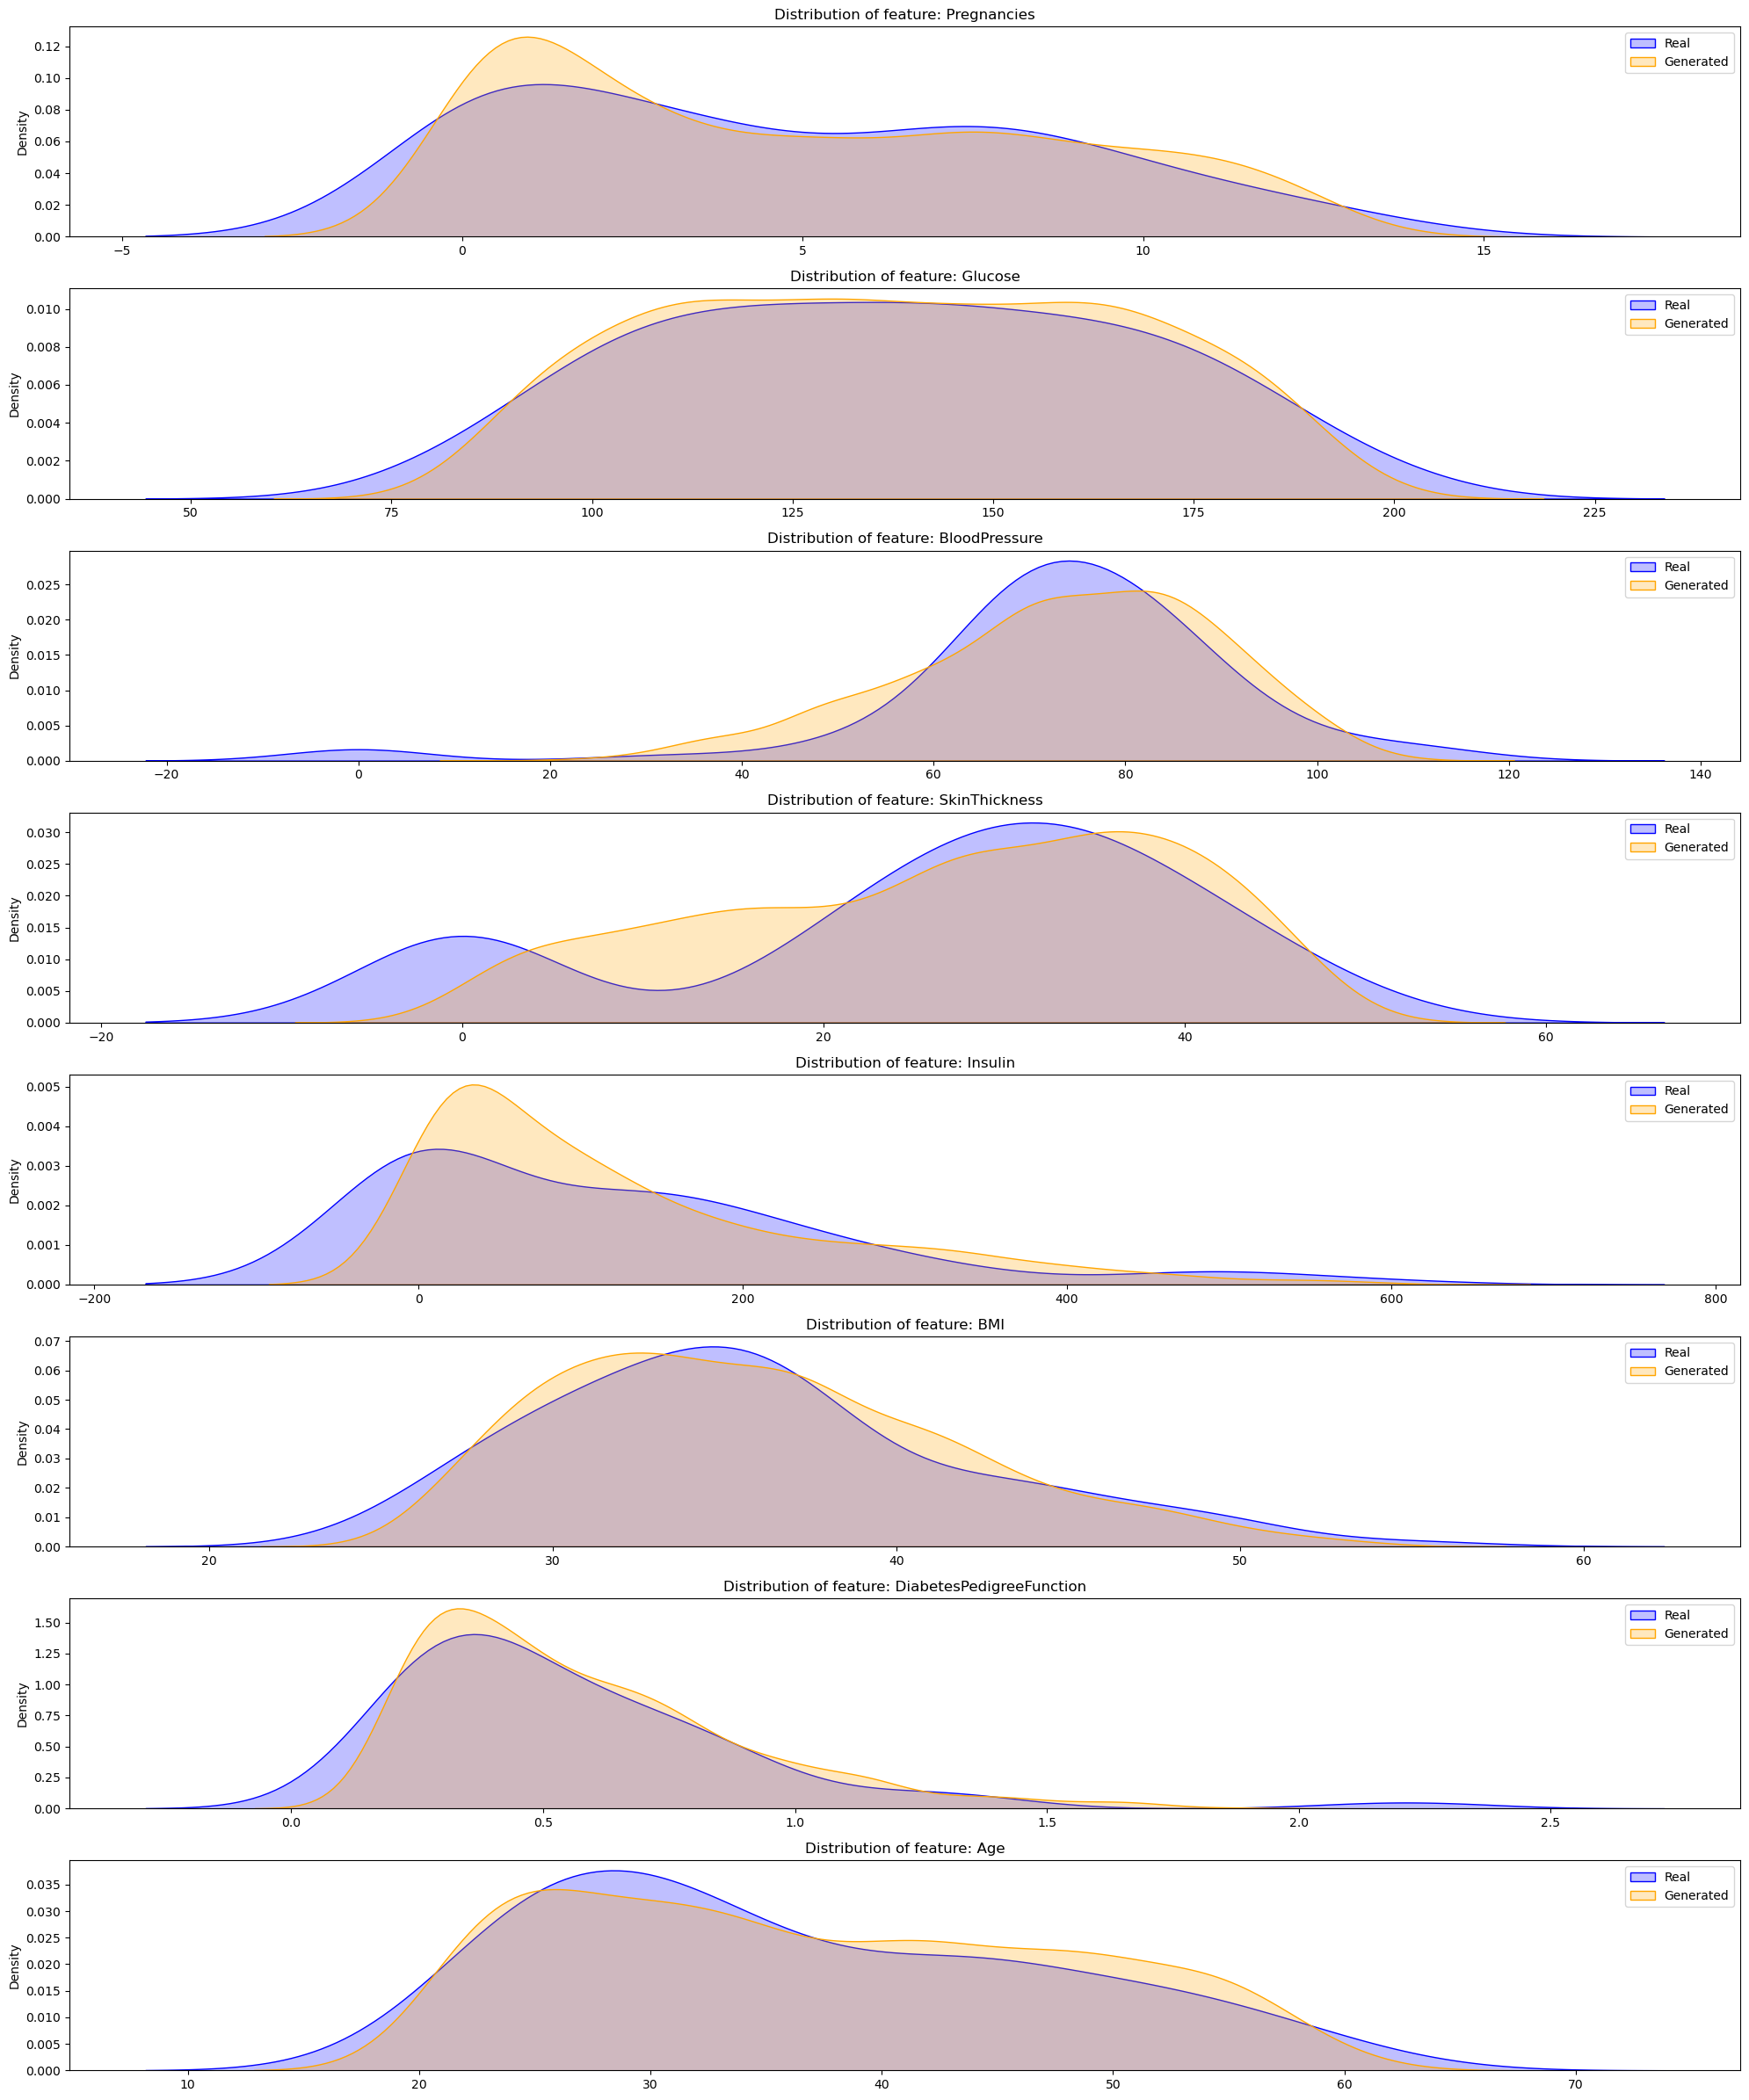

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_distributions(real_data, generated_data, feature_names):
    n_features = real_data.shape[1]
    plt.figure(figsize=(20, n_features * 3))
    
    for i in range(n_features):
        plt.subplot(n_features, 1, i + 1)
        sns.kdeplot(real_data[:, i], label='Real', fill=True, color='blue')
        sns.kdeplot(generated_data[:, i], label='Generated', fill=True, color='orange')
        plt.title(f'Distribution of feature: {feature_names[i]}')
        plt.legend()
        
    plt.tight_layout()
    plt.show()


noise = tf.random.normal([1000, latent_dim])
generated_samples = generator(noise, training=False)
generated_samples = tf.clip_by_value(generated_samples, -1.0, 1.0).numpy()
generated_original = scaler.inverse_transform(generated_samples)

# Plot distributions
plot_feature_distributions(minority_data.values, generated_original, minority_data.columns)


In [48]:
# Number of synthetic samples to generate (balance the dataset)
n_synthetic = len(df[df[target_col] == 0]) - len(df[df[target_col] == 1])

noise = tf.random.normal([n_synthetic, latent_dim])
synthetic_samples = generator(noise, training=False)
synthetic_samples = tf.clip_by_value(synthetic_samples, -1.0, 1.0).numpy()
synthetic_samples_original = scaler.inverse_transform(synthetic_samples)


In [49]:
# Prepare real minority and majority data separately
minority_real = df[df[target_col] == 1].drop(columns=[target_col])
majority_real = df[df[target_col] == 0].drop(columns=[target_col])

# Create DataFrame for synthetic minority samples
synthetic_df = pd.DataFrame(synthetic_samples_original, columns=minority_real.columns)

# Create target column for synthetic samples (all 1s)
synthetic_df[target_col] = 1

# Add target column to real minority and majority data
minority_real[target_col] = 1
majority_real[target_col] = 0

# Combine majority + real minority + synthetic minority
augmented_df = pd.concat([majority_real, minority_real, synthetic_df], ignore_index=True)

print(f"Original dataset size: {len(df)}")
print(f"Augmented dataset size: {len(augmented_df)}")
print(augmented_df[target_col].value_counts())


Original dataset size: 600
Augmented dataset size: 1000
Outcome
0    500
1    500
Name: count, dtype: int64


In [50]:
from sklearn.model_selection import train_test_split

X = augmented_df.drop(columns=[target_col])
y = augmented_df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")


Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89       100
           1       0.87      0.93      0.90       100

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.89       200
weighted avg       0.90      0.90      0.89       200

ROC-AUC Score: 0.9504


#  LSGAN 

In [52]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler


target_col = 'Outcome'

# Extract minority class samples (Outcome == 1)
minority_data = df[df[target_col] == 1].drop(columns=[target_col])

# Scale features to [-1, 1] for tanh activation in generator output
scaler = MinMaxScaler(feature_range=(-1, 1))
minority_scaled = scaler.fit_transform(minority_data)

print(f"Minority data shape: {minority_scaled.shape}")


Minority data shape: (100, 8)


In [53]:
latent_dim = 100
feature_dim = minority_scaled.shape[1]
batch_size = 32
learning_rate = 0.0002


In [54]:
def build_generator():
    noise = layers.Input(shape=(latent_dim,))
    x = layers.Dense(256)(noise)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(feature_dim, activation='tanh')(x)
    return tf.keras.Model(noise, x)

generator = build_generator()
generator.summary()


C:\Users\96277\ds\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_20 (InputLayer)     │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_19 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_20 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 8)              │         4,104 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,616 (643.03 KB)

 Trainable params: 163,080 (637.03 KB)

 Non-trainable params: 1,536 (6.00 KB)

In [55]:
def build_discriminator():
    sample = layers.Input(shape=(feature_dim,))
    x = layers.Dense(512)(sample)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dense(256)(x)
    x = layers.LeakyReLU(alpha=0.2)(x)
    x = layers.Dense(1)(x)  # Linear output for LSGAN
    return tf.keras.Model(sample, x)

discriminator = build_discriminator()
discriminator.summary()


C:\Users\96277\ds\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_21 (InputLayer)     │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 512)            │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_21 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_22 (LeakyReLU)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,193 (532.00 KB)

 Trainable params: 136,193 (532.00 KB)

 Non-trainable params: 0 (0.00 B)

In [56]:
def lsgan_loss(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_pred - y_true))


In [57]:
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate, beta_1=0.5)


In [58]:
@tf.function
def train_discriminator(generator, discriminator, real_samples, batch_size):
    noise = tf.random.normal([batch_size, latent_dim])
    with tf.GradientTape() as tape:
        fake_samples = generator(noise, training=True)
        real_output = discriminator(real_samples, training=True)
        fake_output = discriminator(fake_samples, training=True)

        real_loss = lsgan_loss(tf.ones_like(real_output), real_output)
        fake_loss = lsgan_loss(tf.zeros_like(fake_output), fake_output)
        total_loss = 0.5 * (real_loss + fake_loss)

    grads = tape.gradient(total_loss, discriminator.trainable_variables)
    discriminator_optimizer.apply_gradients(zip(grads, discriminator.trainable_variables))
    return total_loss

@tf.function
def train_generator(generator, discriminator, batch_size):
    noise = tf.random.normal([batch_size, latent_dim])
    with tf.GradientTape() as tape:
        fake_samples = generator(noise, training=True)
        fake_output = discriminator(fake_samples, training=True)
        loss = 0.5 * lsgan_loss(tf.ones_like(fake_output), fake_output)

    grads = tape.gradient(loss, generator.trainable_variables)
    generator_optimizer.apply_gradients(zip(grads, generator.trainable_variables))
    return loss


In [59]:
def train(generator, discriminator, epochs, batch_size):
    dataset = tf.data.Dataset.from_tensor_slices(minority_scaled.astype('float32')) \
                             .shuffle(buffer_size=1024) \
                             .batch(batch_size, drop_remainder=True)

    for epoch in range(epochs):
        for real_samples in dataset:
            d_loss = train_discriminator(generator, discriminator, real_samples, batch_size)
            g_loss = train_generator(generator, discriminator, batch_size)

        if (epoch + 1) % 100 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs}, D Loss: {d_loss.numpy():.4f}, G Loss: {g_loss.numpy():.4f}")
            generate_and_show_samples(generator, scaler, latent_dim)

def generate_and_show_samples(generator, scaler, latent_dim, n_samples=5):
    noise = tf.random.normal([n_samples, latent_dim])
    generated = generator(noise, training=False)
    clipped = tf.clip_by_value(generated, -1.0, 1.0)
    generated_original = scaler.inverse_transform(clipped.numpy())
    print(f"Generated samples:")
    print(generated_original)


In [60]:
train(generator, discriminator, epochs=1000, batch_size=batch_size)


Epoch 1/1000, D Loss: 0.4039, G Loss: 0.3454
Generated samples:
[[  8.813664  108.86315    67.80987    39.267155  542.3554     30.111519
    1.0862076  37.055252 ]
 [  5.7818747 160.68027    51.438766   31.757154  536.9439     47.147354
    1.7523924  27.942268 ]
 [  2.546302  102.284134   43.330856   34.642902  448.84573    38.864254
    1.7283905  36.438736 ]
 [  5.979085  133.40819    79.85057    39.029358  489.99454    32.47015
    1.5212002  35.544746 ]
 [  5.831278  137.73062    28.447968   40.539745  362.38504    32.504387
    1.9540796  47.89629  ]]
Epoch 100/1000, D Loss: 0.1759, G Loss: 0.1950
Generated samples:
[[1.1084273e+00 1.5060957e+02 9.7479561e+01 4.4247662e+01 6.2747688e+01
  3.0846685e+01 2.5876760e-01 3.1939718e+01]
 [3.0846970e+00 1.3696440e+02 6.9026703e+01 4.6348186e+01 1.5427815e+01
  4.6609154e+01 1.8568315e-01 2.6151335e+01]
 [2.8049767e+00 1.7580737e+02 1.1054605e+02 3.5985115e+01 3.0996671e+02
  4.8110394e+01 2.7720749e-01 5.0669975e+01]
 [3.6662945e-01 1.8

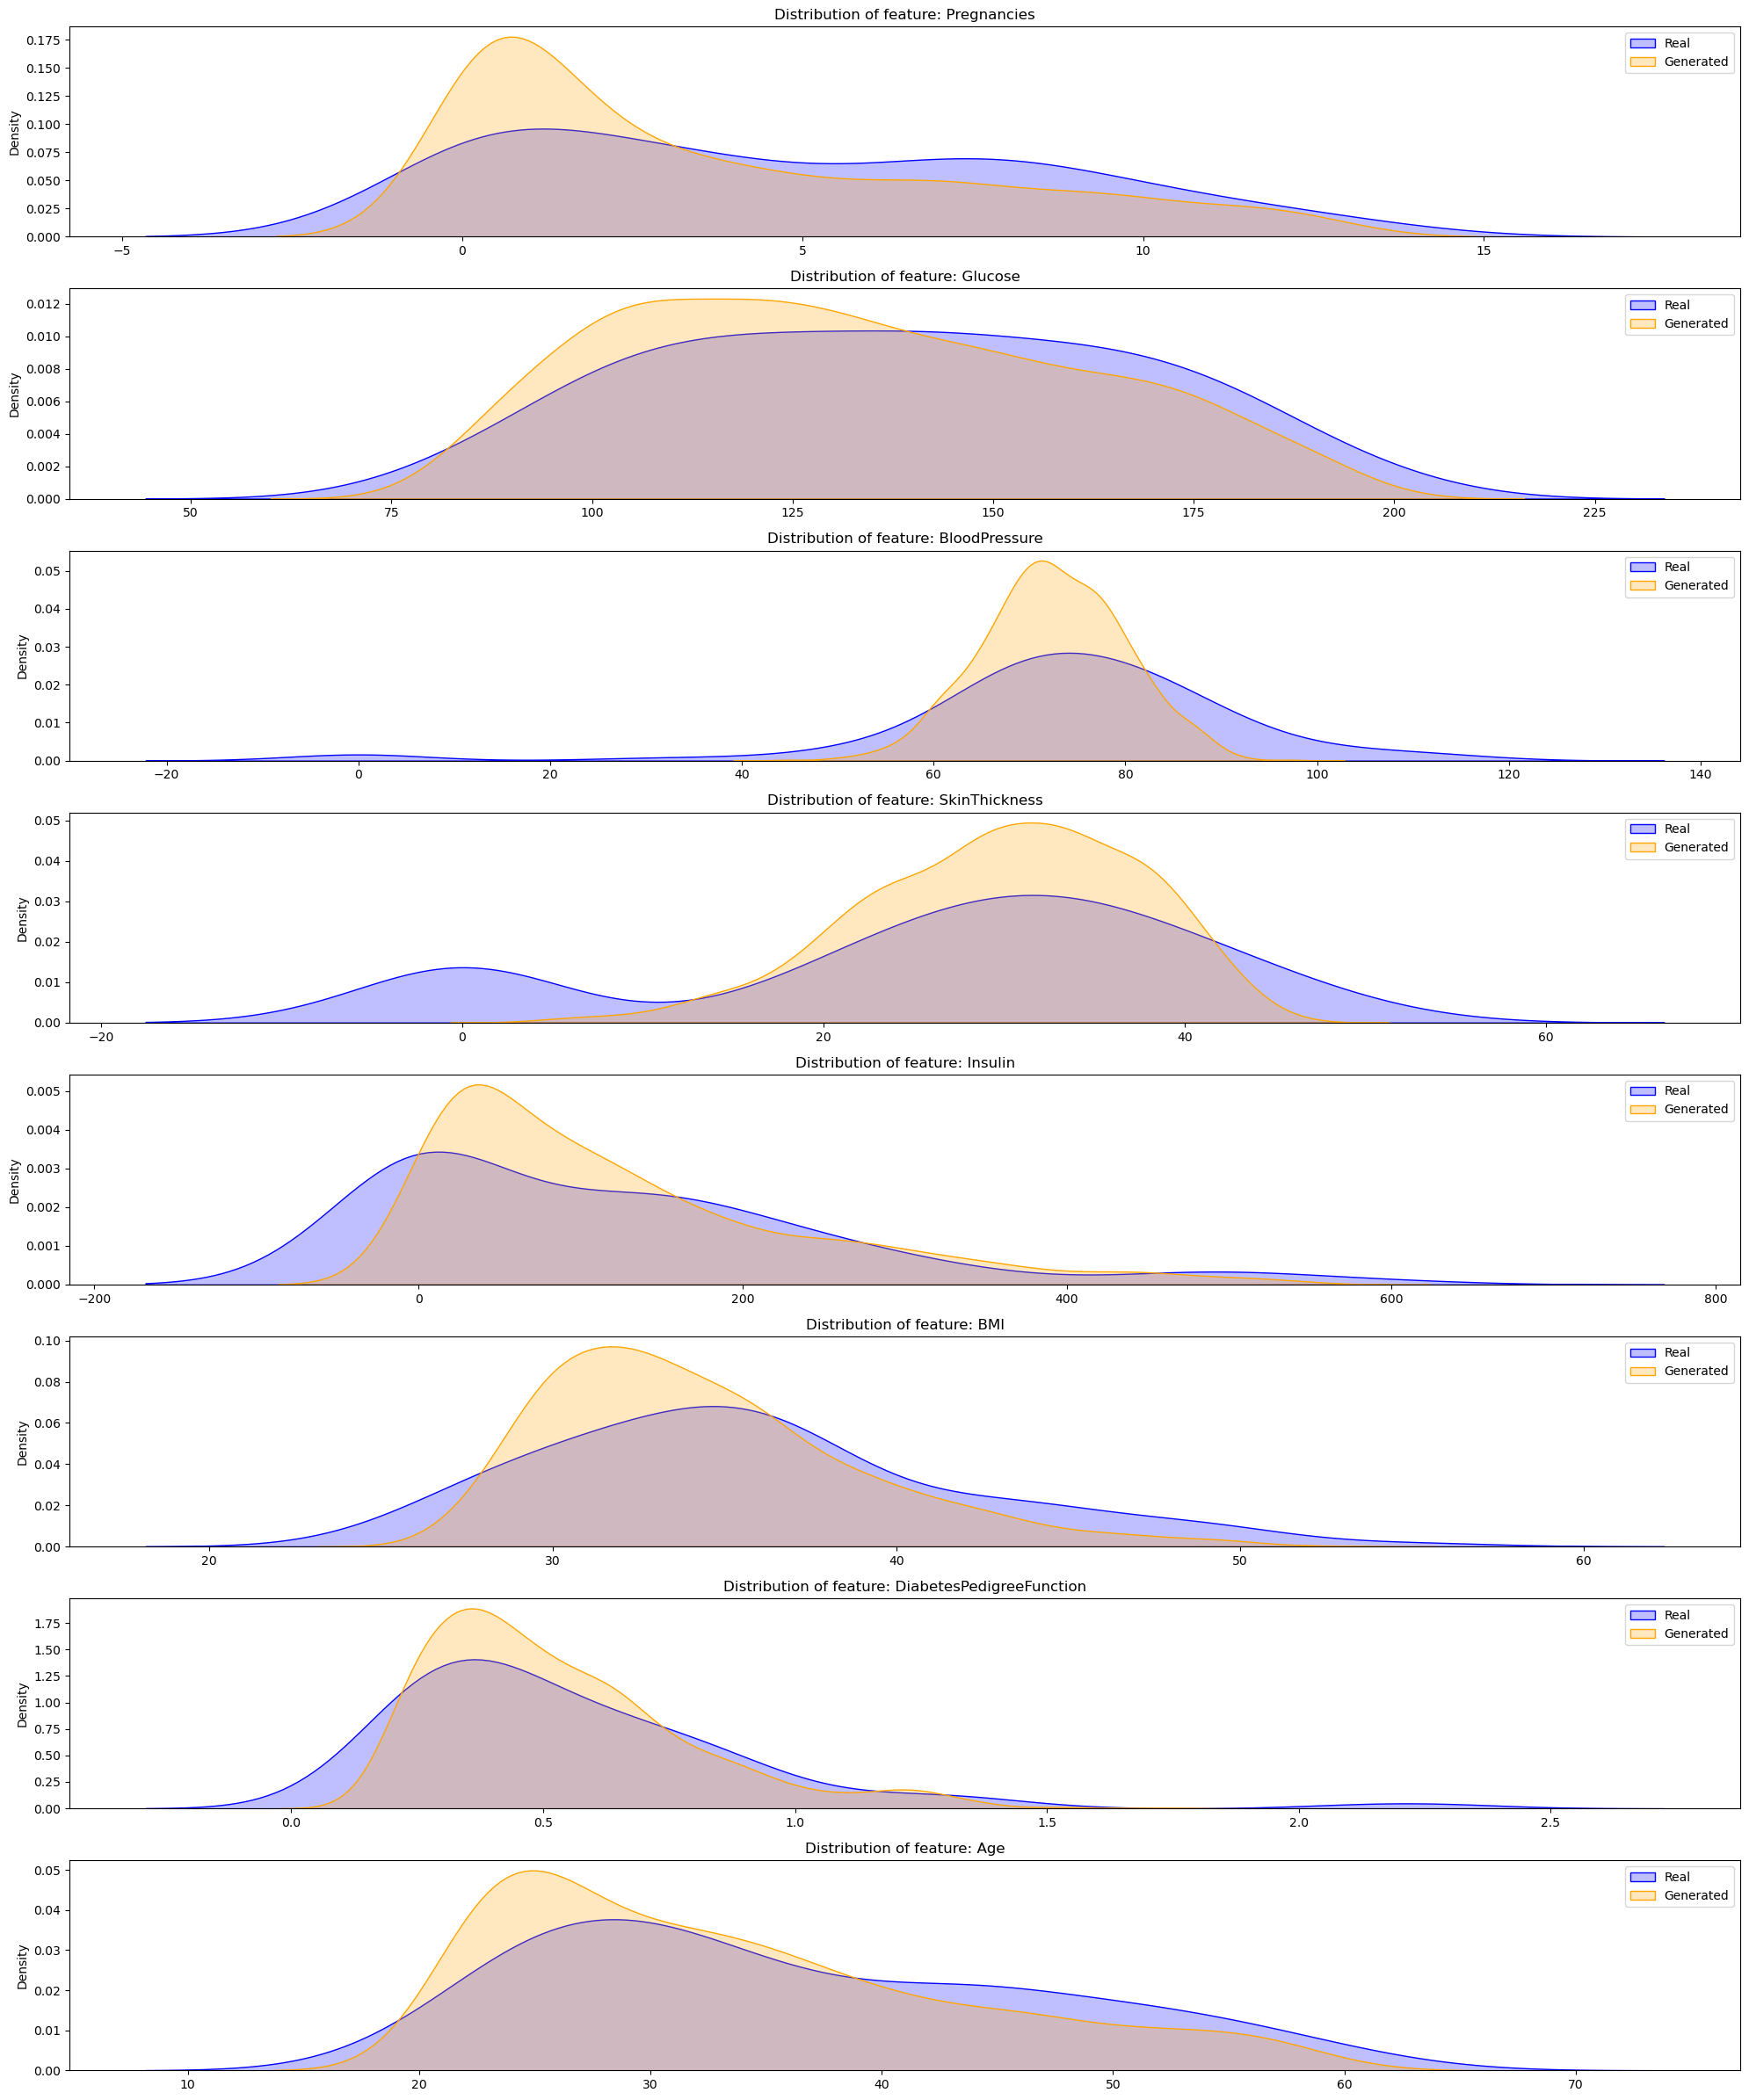

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_distributions(real_data, generated_data, feature_names):
    n_features = real_data.shape[1]
    plt.figure(figsize=(20, n_features * 3))
    
    for i in range(n_features):
        plt.subplot(n_features, 1, i + 1)
        sns.kdeplot(real_data[:, i], label='Real', fill=True, color='blue')
        sns.kdeplot(generated_data[:, i], label='Generated', fill=True, color='orange')
        plt.title(f'Distribution of feature: {feature_names[i]}')
        plt.legend()
        
    plt.tight_layout()
    plt.show()

# Generate a batch of synthetic samples for visualization
noise = tf.random.normal([1000, latent_dim])
generated_samples = generator(noise, training=False)
generated_samples = tf.clip_by_value(generated_samples, -1.0, 1.0).numpy()
generated_original = scaler.inverse_transform(generated_samples)

# Plot distributions
plot_feature_distributions(minority_data.values, generated_original, minority_data.columns)


In [ ]:
import tensorflow as tf

def generate_synthetic_samples(generator_model, scaler, n_samples, latent_dim):
    noise = tf.random.normal([n_samples, latent_dim])
    generated = generator_model(noise, training=False)
    clipped = tf.clip_by_value(generated, -1.0, 1.0)
    generated_original = scaler.inverse_transform(clipped.numpy())
    return generated_original

# Number of synthetic samples needed to balance dataset
num_synthetic = len(df[df[target_col] == 0]) - len(df[df[target_col] == 1])

# Generate synthetic samples for Vanilla GAN
vanilla_synthetic_samples_original = generate_synthetic_samples(generator, scaler, num_synthetic, latent_dim)




In [100]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns

def train_and_evaluate_with_metrics(dataset, target_col):
    X = dataset.drop(columns=[target_col])
    y = dataset[target_col]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    clf = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    cm = confusion_matrix(y_test, y_pred)

    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1-Score: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")
    print("Confusion Matrix:")
    print(cm)

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'confusion_matrix': cm
    }


In [101]:
results = {}

print("Evaluating on Original Dataset")
results['Original'] = train_and_evaluate_with_metrics(dataset_orig, target_col)

print("\nEvaluating on Vanilla GAN Balanced Dataset")
results['Vanilla GAN'] = train_and_evaluate_with_metrics(dataset_vanilla, target_col)

print("\nEvaluating on LS-GAN Balanced Dataset")
results['LS-GAN'] = train_and_evaluate_with_metrics(dataset_lsgan, target_col)

print("\nEvaluating on WGAN-GP Balanced Dataset")
results['WGAN-GP'] = train_and_evaluate_with_metrics(dataset_wgangp, target_col)


Evaluating on Original Dataset
Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91       100
           1       1.00      0.05      0.10        20

    accuracy                           0.84       120
   macro avg       0.92      0.53      0.50       120
weighted avg       0.87      0.84      0.78       120

Accuracy: 0.8417, Precision: 1.0000, Recall: 0.0500, F1-Score: 0.0952, ROC-AUC: 0.5515
Confusion Matrix:
[[100   0]
 [ 19   1]]

Evaluating on Vanilla GAN Balanced Dataset
Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.80      0.76       100
           1       0.78      0.70      0.74       100

    accuracy                           0.75       200
   macro avg       0.75      0.75      0.75       200
weighted avg       0.75      0.75      0.75       200

Accuracy: 0.7500, Precision: 0.7778, Recall: 0.7000, F1-Score: 0.7368, ROC-AUC: 0.8216
Confusion 

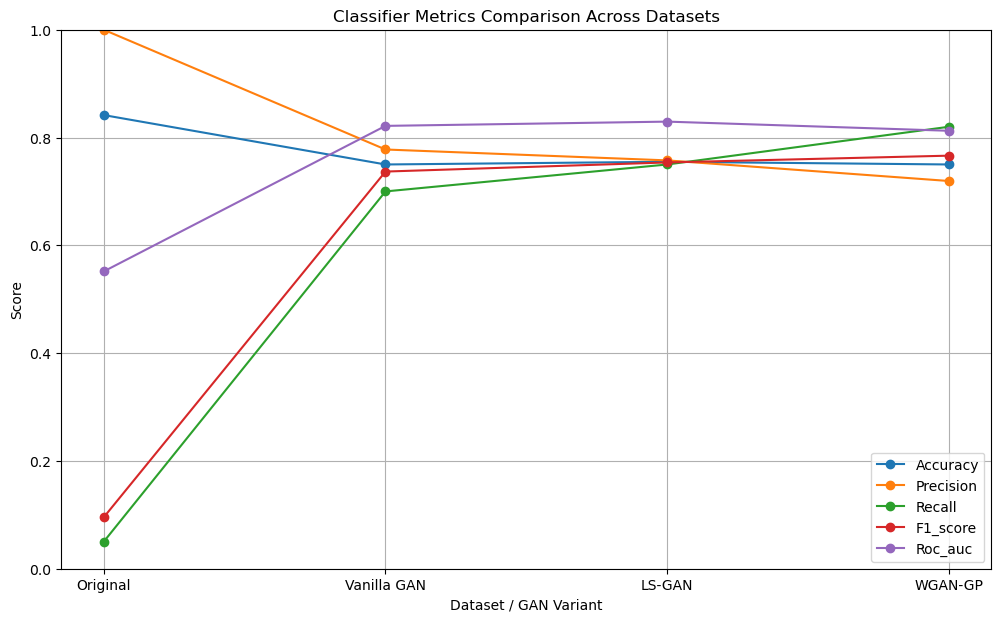

In [77]:
metrics_names = ['accuracy', 'precision', 'recall', 'f1_score', 'roc_auc']
methods = list(results.keys())

plt.figure(figsize=(12, 7))
for metric in metrics_names:
    values = [results[method][metric] for method in methods]
    plt.plot(methods, values, marker='o', label=metric.capitalize())

plt.title("Classifier Metrics Comparison Across Datasets")
plt.xlabel("Dataset / GAN Variant")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()


In [82]:
print("Sample Synthetic Data from Vanilla GAN:")
print(pd.DataFrame(dataset_vanilla).head())

print("\nSample Synthetic Data from LS-GAN:")
print(pd.DataFrame(lsgan_synthetic_samples).head())

print("\nSample Synthetic Data from WGAN-GP:")
print(pd.DataFrame(wgangp_synthetic_samples).head())


Sample Synthetic Data from Vanilla GAN:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0          3.0    111.0           90.0           12.0     78.0  28.4   
1          2.0     94.0           76.0           18.0     66.0  31.6   
2          2.0    107.0           74.0           30.0    100.0  33.6   
3          0.0     78.0           88.0           29.0     40.0  36.9   
4          9.0    134.0           74.0           33.0     60.0  25.9   

   DiabetesPedigreeFunction   Age  Outcome  
0                     0.495  29.0        0  
1                     0.649  23.0        0  
2                     0.404  23.0        0  
3                     0.434  21.0        0  
4                     0.460  81.0        0  

Sample Synthetic Data from LS-GAN:
          0           1          2          3           4          5  \
0  0.312604  134.779648  81.500572  37.613628   16.015255  32.214878   
1  6.400271  129.062042  68.862732  35.974873  117.029930  37.518879   
2  1.

In [ ]:
num_synthetic = len(df[df[target_col] == 0]) - len(df[df[target_col] == 1])


lsgan_synthetic_samples = lsgan_generator(tf.random.normal([num_synthetic, latent_dim]), training=False)
lsgan_synthetic_samples = tf.clip_by_value(lsgan_synthetic_samples, -1, 1).numpy()
lsgan_synthetic_samples_original = scaler.inverse_transform(lsgan_synthetic_samples)

lsgan_synthetic_df = pd.DataFrame(lsgan_synthetic_samples_original, columns=minority_real.columns[:-1])
lsgan_synthetic_df[target_col] = 1  

wgangp_synthetic_samples = wgangp_generator(tf.random.normal([num_synthetic, latent_dim]), training=False)
wgangp_synthetic_samples = tf.clip_by_value(wgangp_synthetic_samples, -1, 1).numpy()
wgangp_synthetic_samples_original = scaler.inverse_transform(wgangp_synthetic_samples)

wgangp_synthetic_df = pd.DataFrame(wgangp_synthetic_samples_original, columns=minority_real.columns[:-1])
wgangp_synthetic_df[target_col] = 1  


vanilla_synthetic_samples = generator(tf.random.normal([num_synthetic, latent_dim]), training=False)
vanilla_synthetic_samples = tf.clip_by_value(vanilla_synthetic_samples, -1, 1).numpy()
vanilla_synthetic_samples_original = scaler.inverse_transform(vanilla_synthetic_samples)

vanilla_synthetic_df = pd.DataFrame(vanilla_synthetic_samples_original, columns=minority_real.columns[:-1])
vanilla_synthetic_df[target_col] = 1


print("Sample Synthetic Data from Vanilla GAN:")
print(vanilla_synthetic_df.head())

print("\nSample Synthetic Data from LS-GAN:")
print(lsgan_synthetic_df.head())

print("\nSample Synthetic Data from WGAN-GP:")
print(wgangp_synthetic_df.head())


Sample Synthetic Data from Vanilla GAN:
   Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
0    11.630731   84.373566      72.843674      37.087036    5.719704   
1     0.111984  144.429672      76.958527      38.526024  131.183716   
2     0.322717  109.158531      62.107048      36.470547  341.145538   
3     0.335523   90.937698      81.455765      37.010212   47.128021   
4     0.032989  168.871201      78.895218      33.535099  346.399384   

         BMI  DiabetesPedigreeFunction        Age  Outcome  
0  31.876221                  1.044335  39.677307        1  
1  45.744572                  0.476885  24.034443        1  
2  34.008881                  0.656734  21.915953        1  
3  43.384190                  0.614989  24.582718        1  
4  38.577049                  0.326031  26.854830        1  

Sample Synthetic Data from LS-GAN:
   Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
0     4.193018   92.202217      79.417496      35.075